<>:78: SyntaxWarning: invalid escape sequence '\g'
<>:83: SyntaxWarning: invalid escape sequence '\D'
<>:85: SyntaxWarning: invalid escape sequence '\g'
<>:78: SyntaxWarning: invalid escape sequence '\g'
<>:83: SyntaxWarning: invalid escape sequence '\D'
<>:85: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_680/1733044029.py:78: SyntaxWarning: invalid escape sequence '\g'
  ax1.set_xlabel('Synthetic Association Parameter ($\gamma$)')
/tmp/ipykernel_680/1733044029.py:83: SyntaxWarning: invalid escape sequence '\D'
  fig.colorbar(c2, ax=ax2, label='M3: Additional Price ($\Delta P$)')
/tmp/ipykernel_680/1733044029.py:85: SyntaxWarning: invalid escape sequence '\g'
  ax2.set_xlabel('Synthetic Association Parameter ($\gamma$)')


--- GENERATING 2D HEATMAP DATA  ---
Saved 'fig_2d_heatmaps.png' to local directory. Upload this to Overleaf!

--- HEATMAP INSIGHTS FOR THE MANUSCRIPT ---
M1 50% Failure Tipping Points:
   Budget $0.40: System collapses at Gamma >= 0.4
   Budget $0.50: System collapses at Gamma >= 0.4
   Budget $0.60: System collapses at Gamma >= 0.4
   Budget $0.70: System collapses at Gamma >= 0.4
   Budget $0.80: System collapses at Gamma >= 0.4
   Budget $0.90: System collapses at Gamma >= 0.4
   Budget $1.00: System collapses at Gamma >= 0.4
   Budget $1.10: System collapses at Gamma >= 0.4
   Budget $1.20: System collapses at Gamma >= 0.4

Maximum Additional Price (Delta P) to maintain health in extreme markets (Gamma=1.0):
   Budget $0.40 -> User must pay an extra $0.26
   Budget $0.50 -> User must pay an extra $0.36
   Budget $0.60 -> User must pay an extra $1.41
   Budget $0.70 -> User must pay an extra $1.41
   Budget $0.80 -> User must pay an extra $1.57
   Budget $0.90 -> User must pay an ex

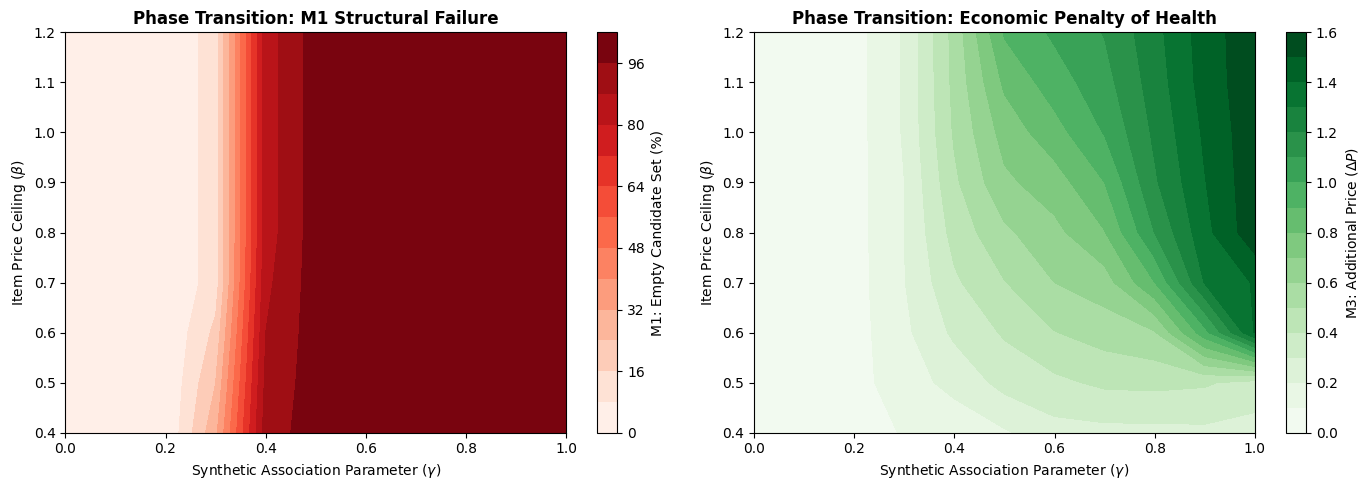

In [1]:
# ==============================================================================
# SCRIPT 04: 2D PHASE-TRANSITION HEATMAPS (BETA vs GAMMA)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt

N, R = 2500, 50 # Scaled down for grid search speed
gamma_grid = np.linspace(0.0, 1.0, 11)
beta_grid = np.linspace(0.40, 1.20, 9)

tau_sod, tau_fat, tau_sug = 600.0, 3.0, 5.0
J_candidates = 50
W_P, W_T = 0.50, 0.50

m1_failure_matrix = np.zeros((len(beta_grid), len(gamma_grid)))
m3_delta_p_matrix = np.zeros((len(beta_grid), len(gamma_grid)))

print("--- GENERATING 2D HEATMAP DATA  ---")
np.random.seed(101)
master_P = np.random.uniform(0.10, 3.00, (R, N))
master_T = np.random.uniform(2.0, 15.0, (R, N))
master_noise_sod = np.random.normal(500, 200, (R, N))
master_noise_fat = np.random.normal(2.5, 1.0, (R, N))
master_noise_sug = np.random.normal(3.5, 1.5, (R, N))

for i, beta in enumerate(beta_grid):
    for j, gamma in enumerate(gamma_grid):

        m1_fails = 0
        delta_p_sum = 0

        for r in range(R):
            P = master_P[r]
            T = master_T[r]
            P_inv = (3.00 - P) / 2.90

            Sod = np.maximum(0, gamma * (1200 * P_inv + 100) + (1 - gamma) * master_noise_sod[r])
            Fat = np.maximum(0, gamma * (5.0 * P_inv + 0.5)  + (1 - gamma) * master_noise_fat[r])
            Sug = np.maximum(0, gamma * (9.0 * P_inv + 1.0)  + (1 - gamma) * master_noise_sug[r])

            U = (W_P * P_inv) + (W_T * ((15.0 - T) / 13.0))

            # M0 Baseline
            idx_m0 = np.argmax(U)
            p_m0 = P[idx_m0]

            # M1 Failure
            top_J = np.argsort(U)[-J_candidates:]
            if not np.any((Sod[top_J] <= tau_sod) & (Fat[top_J] <= tau_fat) & (Sug[top_J] <= tau_sug) & (P[top_J] <= beta)):
                m1_fails += 1

            # M3 Logic (Two-Step)
            strict_mask = (P <= beta) & (Sod <= tau_sod) & (Fat <= tau_fat) & (Sug <= tau_sug)
            if np.any(strict_mask):
                idx_m3 = np.argmax(np.where(strict_mask, U, -np.inf))
            else:
                v_bud = np.maximum(0, P - beta) / beta
                v_sod = np.maximum(0, Sod - tau_sod) / tau_sod
                v_fat = np.maximum(0, Fat - tau_fat) / tau_fat
                v_sug = np.maximum(0, Sug - tau_sug) / tau_sug
                Z = v_bud + v_sod + v_fat + v_sug
                min_Z_mask = np.isclose(Z, np.min(Z), atol=1e-8)
                idx_m3 = np.argmax(np.where(min_Z_mask, U, -np.inf))

            delta_p_sum += (P[idx_m3] - p_m0)

        m1_failure_matrix[i, j] = (m1_fails / R) * 100
        m3_delta_p_matrix[i, j] = delta_p_sum / R

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: M1 Failure Heatmap
X, Y = np.meshgrid(gamma_grid, beta_grid)
c1 = ax1.contourf(X, Y, m1_failure_matrix, levels=15, cmap='Reds')
fig.colorbar(c1, ax=ax1, label='M1: Empty Candidate Set (%)')
ax1.set_title('Phase Transition: M1 Structural Failure', fontweight='bold')
ax1.set_xlabel('Synthetic Association Parameter ($\gamma$)')
ax1.set_ylabel('Item Price Ceiling ($\\beta$)')

# Plot 2: M3 Delta P Heatmap
c2 = ax2.contourf(X, Y, m3_delta_p_matrix, levels=15, cmap='Greens')
fig.colorbar(c2, ax=ax2, label='M3: Additional Price ($\Delta P$)')
ax2.set_title('Phase Transition: Economic Penalty of Health', fontweight='bold')
ax2.set_xlabel('Synthetic Association Parameter ($\gamma$)')
ax2.set_ylabel('Item Price Ceiling ($\\beta$)')

plt.tight_layout()
plt.savefig('fig_2d_heatmaps.png', dpi=300, bbox_inches='tight')
print("Saved 'fig_2d_heatmaps.png' to local directory. Upload this to Overleaf!")

# ------------------------------------------------------------------------------
# EXTRACTING TEXT-BASED INSIGHTS FROM THE HEATMAPS
# ------------------------------------------------------------------------------
print("\n--- HEATMAP INSIGHTS FOR THE MANUSCRIPT ---")

# 1. At what market hostility (Gamma) does M1 cross a 50% failure rate for different budgets?
print("M1 50% Failure Tipping Points:")
for i, beta in enumerate(beta_grid):
    failing_gammas = gamma_grid[m1_failure_matrix[i, :] >= 50.0]
    if len(failing_gammas) > 0:
        print(f"   Budget ${beta:.2f}: System collapses at Gamma >= {failing_gammas[0]:.1f}")
    else:
        print(f"   Budget ${beta:.2f}: System never reaches 50% failure.")

# 2. What is the maximum "Health Tax" (Delta P) imposed on users in extreme markets?
print("\nMaximum Additional Price (Delta P) to maintain health in extreme markets (Gamma=1.0):")
gamma_1_idx = np.where(np.isclose(gamma_grid, 1.0))[0][0]
for i, beta in enumerate(beta_grid):
    delta_p = m3_delta_p_matrix[i, gamma_1_idx]
    print(f"   Budget ${beta:.2f} -> User must pay an extra ${delta_p:.2f}")